# Return of Investment - Education
### Wstęp do analizy danych - czyli jak korelują studia z przyszłymi zarobkami
**Autor:** Paulina Kania  
**Data:** 2026-sty

---
# Wstęp

## Cel projektu
> *"Czy ścieżka STEM to jedyna droga do sukcesu w Stanach Zjednoczonych"*

Ameryka jest jednym z najbardziej skomplikowanych państw na świecie – z bardzo intrygującym systemem edukacji. Moim głównym zamysłem początkowo było dokonanie analizy kierunków powiązanych z popularnym określeniem **"STEM" – science, technology, engineering and mathematics**, gdyż kierunki i uczelnie z tym słowem powiązane są najbliższe motywowi edukacji AGH. Jednakże przy aktualnej dominacji rynku technologicznego (STEM) nad pozostałymi dziedzinami, np. humanistycznymi (liberal arts), warto też porównać zarobki absolwenta informatyki (Computer Science) do przykładowo historyka (History). Dane z Kaggle są co prawda lekko przestarzałe (ponieważ powstały 9 lat temu), jednak trend wzrostu technologicznego pojawił się długo przedtem. Należy pamiętać, że od tego czasu rynek technologiczny przeszedł dynamiczne zmiany (rozwój AI i pandemia), co mogło jeszcze bardziej powiększyć dystans między STEM a innymi dziedzinami. Istnieje popularny motyw, o którym głośno na zagranicznych portalach społecznościowych – o „humanistycznym długu", czyli fakt, iż zadłużenie studenckie (student loans) przerasta średnie zarobki po ukończeniu studiów. W poniższej analizie postaram się przybliżyć zagadnienia związane z wybranym tematem.

## Dane użyte w analizie

Dane pochodzą z: https://www.kaggle.com/datasets/wsj/college-salaries?resource=download

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
import seaborn as sns
# from scipy import stats

# Ustawienia wyświetlania
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'

In [7]:
# Pobieranie danych z plików pobranych ze strony Kaggle
degrees_that_pay_back = pd.read_csv('data/degrees-that-pay-back.csv')
salaries_by_college_type = pd.read_csv('data/salaries-by-college-type.csv')
salaries_by_region = pd.read_csv('data/salaries-by-region.csv')

### Zawartość i Struktura

In [8]:
print("=== degrees-that-pay-back ===")
print(degrees_that_pay_back.info())
print("\n=== salaries-by-college-type ===")
print(salaries_by_college_type.info())
print("\n=== salaries-by-region ===")
print(salaries_by_region.info())

=== degrees-that-pay-back ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Undergraduate Major                                50 non-null     str    
 1   Starting Median Salary                             50 non-null     str    
 2   Mid-Career Median Salary                           50 non-null     str    
 3   Percent change from Starting to Mid-Career Salary  50 non-null     float64
 4   Mid-Career 10th Percentile Salary                  50 non-null     str    
 5   Mid-Career 25th Percentile Salary                  50 non-null     str    
 6   Mid-Career 75th Percentile Salary                  50 non-null     str    
 7   Mid-Career 90th Percentile Salary                  50 non-null     str    
dtypes: float64(1), str(7)
memory usage: 6.9 KB
None

=== salaries-by-college-t

---
# Przygotowanie danych

## Biblioteki
- **pandas** – podstawowa biblioteka do analizy danych
- **numpy** – operacje numeryczne
- **matplotlib / seaborn** – wizualizacje
- **scipy** – statystyki i korelacje

## Data Cleaning

### degrees-that-pay-back.csv

In [97]:
degree = degrees_that_pay_back.copy()
print(degree.dtypes)
print(degree.head())

Undergraduate Major                                      str
Starting Median Salary                                   str
Mid-Career Median Salary                                 str
Percent change from Starting to Mid-Career Salary    float64
Mid-Career 10th Percentile Salary                        str
Mid-Career 25th Percentile Salary                        str
Mid-Career 75th Percentile Salary                        str
Mid-Career 90th Percentile Salary                        str
dtype: object
     Undergraduate Major Starting Median Salary Mid-Career Median Salary  \
0             Accounting             $46,000.00               $77,100.00   
1  Aerospace Engineering             $57,700.00              $101,000.00   
2            Agriculture             $42,600.00               $71,900.00   
3           Anthropology             $36,800.00               $61,500.00   
4           Architecture             $41,600.00               $76,800.00   

   Percent change from Starting to Mid-Ca

Na pierwszy rzut oka można zauważyć już wstępne problemy, czyli bardzo długie tytuły kolumn jak i nieużywalny format danych zapisanych jako `object` zamiast `float`.

In [98]:
degree = degree.rename(columns={
    'Undergraduate Major': 'major',
    'Starting Median Salary': 'career_start',
    'Mid-Career Median Salary': 'career_mid',
    'Percent change from Starting to Mid-Career Salary': 'p_change',
    'Mid-Career 10th Percentile Salary': 'p10_salary',
    'Mid-Career 25th Percentile Salary': 'p25_salary',
    'Mid-Career 75th Percentile Salary': 'p75_salary',
    'Mid-Career 90th Percentile Salary': 'p90_salary'
})

print(degree.columns.tolist())

salary_cols = ['career_start', 'career_mid', 'p10_salary', 'p25_salary', 'p75_salary', 'p90_salary']
for col in salary_cols:
    degree[col] = degree[col].replace(r'[\$,]', '', regex=True).replace('N/A', np.nan).astype(float)

# kolumna p_change to: (career_mid - career_start) / career_start * 100
degree['p_change'] = degree['p_change'].replace('%', '', regex=True).astype(float)

degree.head()

['major', 'career_start', 'career_mid', 'p_change', 'p10_salary', 'p25_salary', 'p75_salary', 'p90_salary']


,major,career_start,career_mid,p_change,p10_salary,p25_salary,p75_salary,p90_salary
0,Accounting,46000.00,77100.00,67.60,42200.00,56100.00,108000.00,152000.00
1,Aerospace Engineering,57700.00,101000.00,75.00,64300.00,82100.00,127000.00,161000.00
2,Agriculture,42600.00,71900.00,68.80,36300.00,52100.00,96300.00,150000.00
3,Anthropology,36800.00,61500.00,67.10,33800.00,45500.00,89300.00,138000.00
4,Architecture,41600.00,76800.00,84.60,50600.00,62200.00,97000.00,136000.00


Teraz kolej na pozostałe pliki - które wykonam analogicznie.

### salaries-by-college-type.csv

In [99]:
college = salaries_by_college_type.copy()
print(college.dtypes)

college = college.rename(columns={
    'School Name': 'university',
    'School Type': 'type',
    'Starting Median Salary': 'career_start',
    'Mid-Career Median Salary': 'career_mid',
    'Mid-Career 10th Percentile Salary': 'p10_salary',
    'Mid-Career 25th Percentile Salary': 'p25_salary',
    'Mid-Career 75th Percentile Salary': 'p75_salary',
    'Mid-Career 90th Percentile Salary': 'p90_salary'
})

for col in salary_cols:
    college[col] = college[col].replace(r'[\$,]', '', regex=True).replace('N/A', np.nan).astype(float)

college.head()

School Name                          str
School Type                          str
Starting Median Salary               str
Mid-Career Median Salary             str
Mid-Career 10th Percentile Salary    str
Mid-Career 25th Percentile Salary    str
Mid-Career 75th Percentile Salary    str
Mid-Career 90th Percentile Salary    str
dtype: object


,university,type,career_start,career_mid,p10_salary,p25_salary,p75_salary,p90_salary
0,Massachusetts Institute of Technology (MIT),Engineering,72200.00,126000.00,76800.00,99200.00,168000.00,220000.00
1,California Institute of Technology (CIT),Engineering,75500.00,123000.00,NaN,104000.00,161000.00,NaN
2,Harvey Mudd College,Engineering,71800.00,122000.00,NaN,96000.00,180000.00,NaN
3,"Polytechnic University of New York, Brooklyn",Engineering,62400.00,114000.00,66800.00,94300.00,143000.00,190000.00
4,Cooper Union,Engineering,62200.00,114000.00,NaN,80200.00,142000.00,NaN


Zauważyłam już przy pierwszym wglądzie w dane, iż jest dużo brakujących pozycji w kolumnach percentylowych. Przy konwersji kolumn na typ numeryczny, tekstowy zapis `N/A` zmienił się na prawdziwy `NaN`, przez co łatwo wykryjemy, gdzie dokładnie mamy dziury w danych.

Jedyne braki danych mamy w uzupełniających się kolumnach 90- i 10-percentylowych, więc w dalszej analizie albo musimy znaleźć sposób na ominięcie ich, albo używać 25- i 75-percentyli.

In [100]:
print("Braki danych w college:")
print(college.isnull().sum())

Braki danych w college:
university       0
type             0
career_start     0
career_mid       0
p10_salary      38
p25_salary       0
p75_salary       0
p90_salary      38
dtype: int64


### salaries-by-region.csv

In [101]:
region = salaries_by_region.copy()
print(region.dtypes)

region = region.rename(columns={
    'School Name': 'university',
    'Region': 'Region',
    'Starting Median Salary': 'career_start',
    'Mid-Career Median Salary': 'career_mid',
    'Mid-Career 10th Percentile Salary': 'p10_salary',
    'Mid-Career 25th Percentile Salary': 'p25_salary',
    'Mid-Career 75th Percentile Salary': 'p75_salary',
    'Mid-Career 90th Percentile Salary': 'p90_salary'
})

for col in salary_cols:
    region[col] = region[col].replace(r'[\$,]', '', regex=True).replace('N/A', np.nan).astype(float)

region.head()

School Name                          str
Region                               str
Starting Median Salary               str
Mid-Career Median Salary             str
Mid-Career 10th Percentile Salary    str
Mid-Career 25th Percentile Salary    str
Mid-Career 75th Percentile Salary    str
Mid-Career 90th Percentile Salary    str
dtype: object


,university,Region,career_start,career_mid,p10_salary,p25_salary,p75_salary,p90_salary
0,Stanford University,California,70400.00,129000.00,68400.00,93100.00,184000.00,257000.00
1,California Institute of Technology (CIT),California,75500.00,123000.00,NaN,104000.00,161000.00,NaN
2,Harvey Mudd College,California,71800.00,122000.00,NaN,96000.00,180000.00,NaN
3,"University of California, Berkeley",California,59900.00,112000.00,59500.00,81000.00,149000.00,201000.00
4,Occidental College,California,51900.00,105000.00,NaN,54800.00,157000.00,NaN


---
# Exploratory Data Analysis (EDA)

## Pytania Badawcze

### Pytanie 1: Czy dominacja STEM to fakt czy mit?
Porównanie podstawowych statystyk opisowych (mediana, średnia, odchylenie standardowe) dla kierunków STEM oraz pozostałych dziedzin na początku i w środku kariery.

Mając tabelę `degree`, widać wszystkie reprezentowane kierunki studiowania, ale bez dokładnego oznaczenia, do których typów studiów (STEM, humanistyczne czy zarządzanie) należą. Ustalamy typ studiów jak i ogólną kategorię – dla uproszczenia analizy będzie to STEM vs Others.

In [102]:
engineering = [
    "Aerospace Engineering", "Chemical Engineering", "Civil Engineering",
    "Computer Engineering", "Electrical Engineering", "Industrial Engineering",
    "Mechanical Engineering", "Architecture"
]

tech = [
    "Computer Science", "Information Technology (IT)",
    "Management Information Systems (MIS)"
]

math = ["Math"]

science = [
    "Biology", "Chemistry", "Geology", "Physics",
    "Nursing", "Nutrition", "Physician Assistant"
]

liberalart = [
    "Anthropology", "Art History", "Communications", "Criminal Justice",
    "Drama", "Education", "English", "Film", "Geography", "History",
    "Journalism", "Music", "Philosophy", "Political Science",
    "Psychology", "Religion", "Sociology", "Spanish", "International Relations"
]

business = [
    "Accounting", "Business Management", "Economics", "Finance",
    "Marketing", "Hospitality & Tourism", "Health Care Administration",
    "Construction", "Agriculture", "Forestry", "Graphic Design", "Interior Design"
]

def assign_type(major):
    if major in engineering: return "Engineering"
    if major in tech: return "Technology"
    if major in math: return "Mathematics"
    if major in science: return "Science"
    if major in liberalart: return "Liberal Arts"
    if major in business: return "Business"
    return None

degree['type'] = degree['major'].apply(assign_type)
print("Nowe kolumny:", degree.columns.tolist())
print(degree['type'].value_counts())

degree['category'] = degree['type'].apply(
    lambda t: 'STEM' if t in ['Engineering', 'Technology', 'Mathematics', 'Science'] else 'Others'
)
print(degree['category'].value_counts())
print(f"Liczba przypisanych typów: {degree['type'].notna().sum()}")

Nowe kolumny: ['major', 'career_start', 'career_mid', 'p_change', 'p10_salary', 'p25_salary', 'p75_salary', 'p90_salary', 'type']
type
Liberal Arts    19
Business        12
Engineering      8
Science          7
Technology       3
Mathematics      1
Name: count, dtype: int64
category
Others    31
STEM      19
Name: count, dtype: int64
Liczba przypisanych typów: 50


Patrząc wstępnie na liczbę występowania każdego typu studiów, musimy zwrócić uwagę na jeden kierunek matematyczny. W polskim systemie posiadamy matematykę stosowaną, fizyczną i tym podobne, ale na liście niestety nie ma takich wyróżnień. Poza tym podział jest w miarę zrównoważony z zauważalnym wyżem w Liberal Arts jak i Business.

In [103]:
# Statystyka opisowa - zarobki startowe
degreestart = degree.groupby('category')['career_start'].agg(
    mean_start='mean',
    median_start='median',
    max_start='max',
    min_start='min',
    sd_start='std'
).T
degreestart['range'] = degreestart.max(axis=1) - degreestart.min(axis=1)  # przybliżenie
display(degreestart)

stem_mean   = degree.groupby('category')['career_start'].mean()['STEM']
others_mean = degree.groupby('category')['career_start'].mean()['Others']

print(f"Przewaga średniej STEM (x): {stem_mean / others_mean:.2f}")
print(f"Różnica średniej STEM ($):  {stem_mean - others_mean:.2f}")

category,Others,STEM,range
mean_start,39290.32,52500.00,13209.68
median_start,38000.00,53900.00,15900.00
max_start,53700.00,74300.00,20600.00
min_start,34000.00,38800.00,4800.00
sd_start,4750.39,9312.83,4562.44


Przewaga średniej STEM (x): 1.34
Różnica średniej STEM ($):  13209.68


Już w pierwszej analizie statystycznej widać różnicę między kierunkami technicznymi a pozostałymi. Średnia zarobków jest prawie 34% wyższa dla absolwentów STEM już na początku kariery – a co ciekawe, mediana dla STEM jest prawie równa wartości maksymalnej dla pozostałych kierunków.

In [104]:
# Statystyka opisowa - zarobki po 10 latach
degreemid = degree.groupby('category')['career_mid'].agg(
    mean_mid='mean',
    median_mid='median',
    max_mid='max',
    min_mid='min',
    sd_mid='std'
).T
display(degreemid)

stem_mid   = degree.groupby('category')['career_mid'].mean()['STEM']
others_mid = degree.groupby('category')['career_mid'].mean()['Others']

print(f"Przewaga średniej STEM (x): {stem_mid / others_mid:.2f}")
print(f"Różnica średniej STEM ($):  {stem_mid - others_mid:.2f}")

category,Others,STEM
mean_mid,67329.03,86952.63
median_mid,64900.00,91700.00
max_mid,98600.00,107000.00
min_mid,52000.00,55300.00
sd_mid,12037.00,14529.68


Przewaga średniej STEM (x): 1.29
Różnica średniej STEM ($):  19623.60


Z ciekawszych obserwacji: mimo wzrostu różnicy średnich w środku kariery (porównując do początkowej wartości), różnica procentowa zmalała.

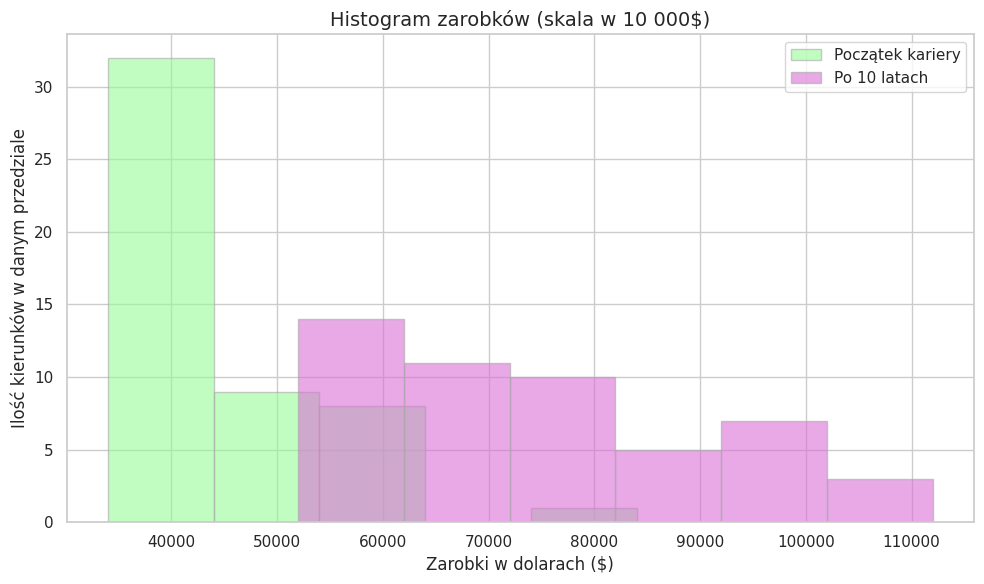

In [105]:
# Histogram zarobków startowych i po 10 latach
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(degree['career_start'],
        bins=range(int(degree['career_start'].min()), int(degree['career_start'].max()) + 10001, 10000),
        color='palegreen', edgecolor='darkgray', alpha=0.6, label='Początek kariery')

ax.hist(degree['career_mid'],
        bins=range(int(degree['career_mid'].min()), int(degree['career_mid'].max()) + 10001, 10000),
        color='orchid', edgecolor='darkgray', alpha=0.6, label='Po 10 latach')

ax.set_title('Histogram zarobków (skala w 10 000$)', fontsize=14)
ax.set_xlabel('Zarobki w dolarach ($)')
ax.set_ylabel('Ilość kierunków w danym przedziale')
ax.legend()
plt.tight_layout()
plt.show()

### Pytanie 2: Jak wygląda prędkość rozwoju wynagrodzeń?
Identyfikacja kierunków o największym i najmniejszym przyroście płac w czasie, czy absolwenci nauk humanistycznych z czasem zmniejszają dystans finansowy do grup STEM.

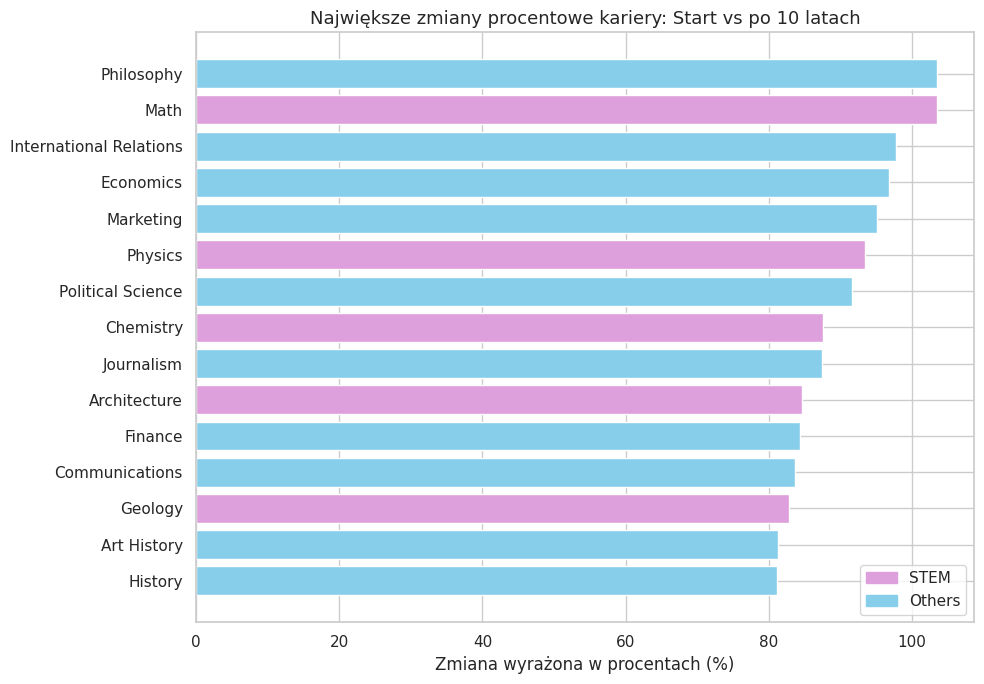

In [106]:
# Top 15 - największe zmiany procentowe
top15 = degree.nlargest(15, 'p_change').sort_values('p_change')

fig, ax = plt.subplots(figsize=(10, 7))
colors = top15['category'].map({'STEM': 'plum', 'Others': 'skyblue'})
ax.barh(top15['major'], top15['p_change'], color=colors)

stem_patch   = mpatches.Patch(color='plum',    label='STEM')
others_patch = mpatches.Patch(color='skyblue', label='Others')
ax.legend(handles=[stem_patch, others_patch])
ax.set_title('Największe zmiany procentowe kariery: Start vs po 10 latach', fontsize=13)
ax.set_xlabel('Zmiana wyrażona w procentach (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

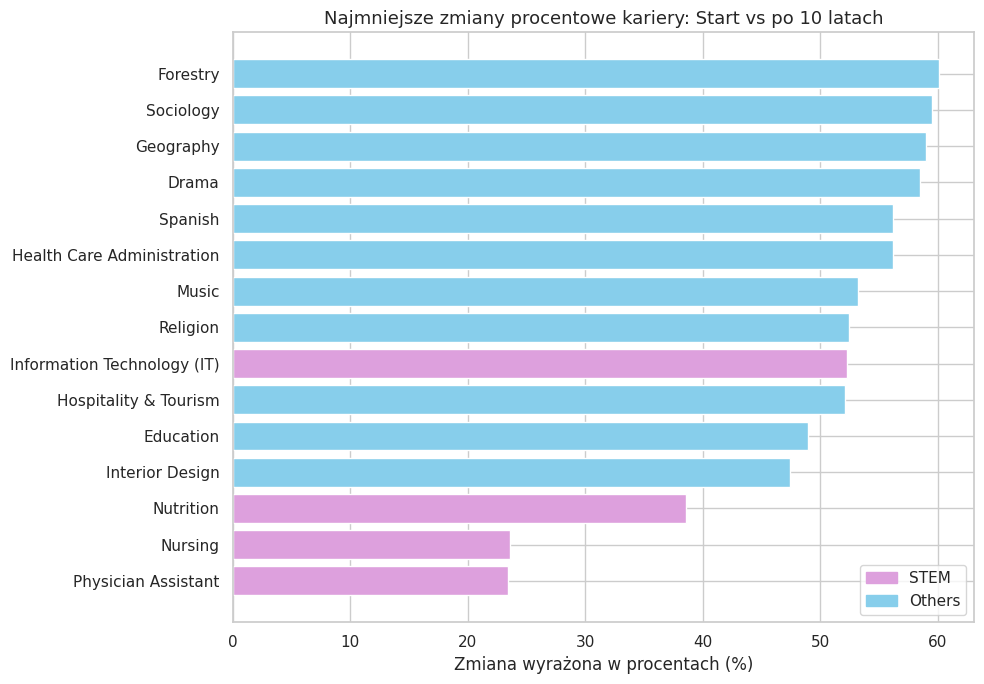

In [107]:
# Bottom 15 - najmniejsze zmiany procentowe
bot15 = degree.nsmallest(15, 'p_change').sort_values('p_change')

fig, ax = plt.subplots(figsize=(10, 7))
colors = bot15['category'].map({'STEM': 'plum', 'Others': 'skyblue'})
ax.barh(bot15['major'], bot15['p_change'], color=colors)

ax.legend(handles=[stem_patch, others_patch])
ax.set_title('Najmniejsze zmiany procentowe kariery: Start vs po 10 latach', fontsize=13)
ax.set_xlabel('Zmiana wyrażona w procentach (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Choć inżynierowie zarabiają więcej kwotowo - humaniści i "biznesowcy" wykazują się dynamiczną adaptacją. Co zaskakujące, dwa kierunki medyczne - Asystent lekarski i Pielęgniarstwo ukazują odchylenie od reszty pod względem braku rozwoju. Mają świetny start ale bardzo mały „sufit".

           type                        major  career_start  career_mid  \
0       Science                      Nursing      54200.00    67000.00   
1  Liberal Arts               Communications      38100.00    70000.00   
2  Liberal Arts                      History      39200.00    71000.00   
3    Technology  Information Technology (IT)      49100.00    74800.00   
4      Business                   Accounting      46000.00    77100.00   

   p_change  p10_salary  p25_salary  p75_salary  p90_salary category  
0     23.60    47600.00    56400.00    80900.00    98300.00     STEM  
1     83.70    37500.00    49700.00    98800.00   143000.00   Others  
2     81.10    37000.00    49200.00   103000.00   149000.00   Others  
3     52.30    44500.00    56700.00    96700.00   129000.00     STEM  
4     67.60    42200.00    56100.00   108000.00   152000.00   Others  


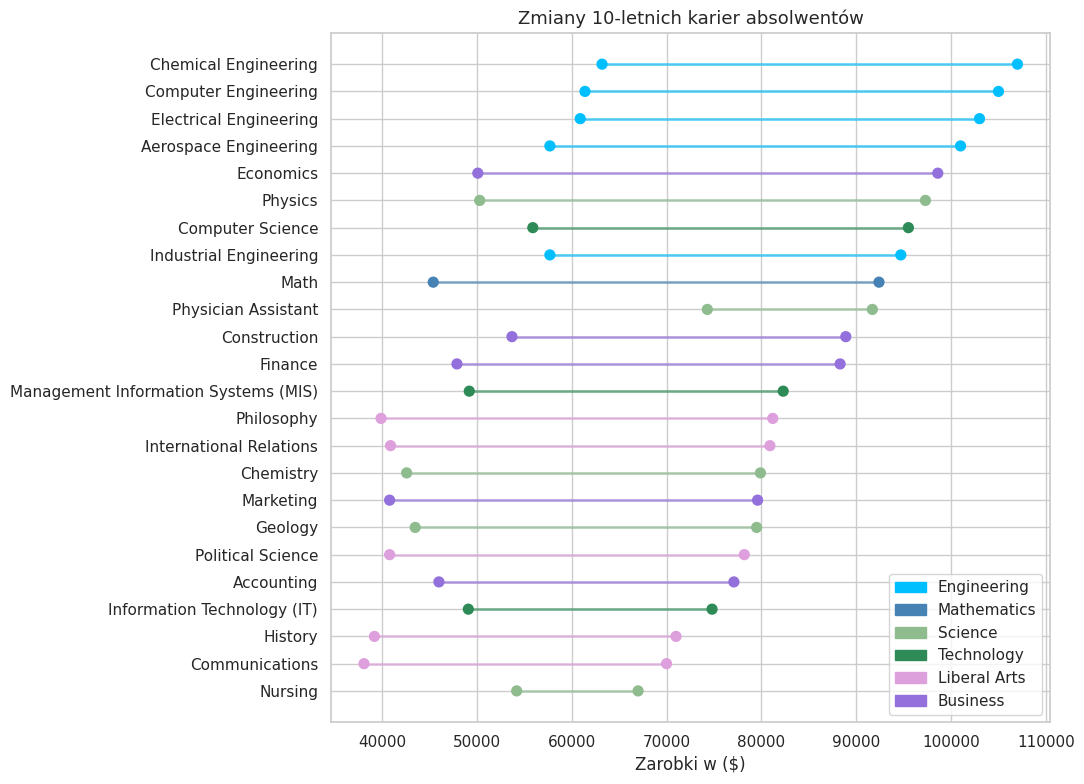

In [108]:
# Wykres dumbbell - zmiany 10-letnich karier (top 5 per type)
type_colors = {
    'Engineering': 'deepskyblue',
    'Mathematics': 'steelblue',
    'Science': 'darkseagreen',
    'Technology': 'seagreen',
    'Liberal Arts': 'plum',
    'Business': 'mediumpurple'
}

top5_per_type = (
    degree.groupby('type') #group_keys=False
    .apply(lambda g: g.nlargest(5, 'career_mid'))#.assign(type=g.name)
    .reset_index(level=0)
    .sort_values('career_mid')
    .reset_index(drop=True)
)

print(top5_per_type.head())

colors = top5_per_type['type'].map(type_colors).fillna('gray')

fig, ax = plt.subplots(figsize=(11, 8))
ax.hlines(y=top5_per_type['major'],
          xmin=top5_per_type['career_start'],
          xmax=top5_per_type['career_mid'],
          color=colors, linewidth=2, alpha=0.6)

ax.scatter(top5_per_type['career_start'], top5_per_type['major'],
           c=colors, s=50, zorder=3)

ax.scatter(top5_per_type['career_mid'], top5_per_type['major'],
           c=colors, s=50, zorder=4)

handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=handles, loc='lower right')
ax.set_title('Zmiany 10-letnich karier absolwentów', fontsize=13)
ax.set_xlabel('Zarobki w ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Pytanie 3: Wewnętrzna hierarchia „Imperium STEM" - która dziedzina dominuje?

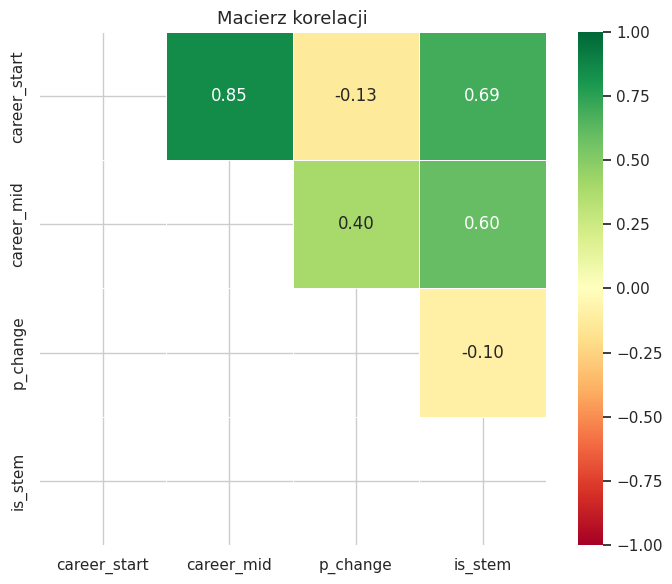

In [109]:
# Macierz korelacji
cor_data = degree[['career_start', 'career_mid', 'p_change']].copy()
cor_data['is_stem'] = degree['category'].apply(lambda x: 1 if x == 'STEM' else 0)
cor_matrix = cor_data.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.tril(np.ones_like(cor_matrix, dtype=bool), k=-1)
np.fill_diagonal(mask, True)
sns.heatmap(
    cor_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Macierz korelacji', fontsize=13)
plt.tight_layout()
plt.show()

Macierz korelacji pokazuje silną dodatnią zależność między przynależnością do grupy STEM a wynagrodzeniem początkowym (z ujemną korelacją co do procentu zmiany) – warto zadać pytanie: która z subdziedzin faktycznie króluje...

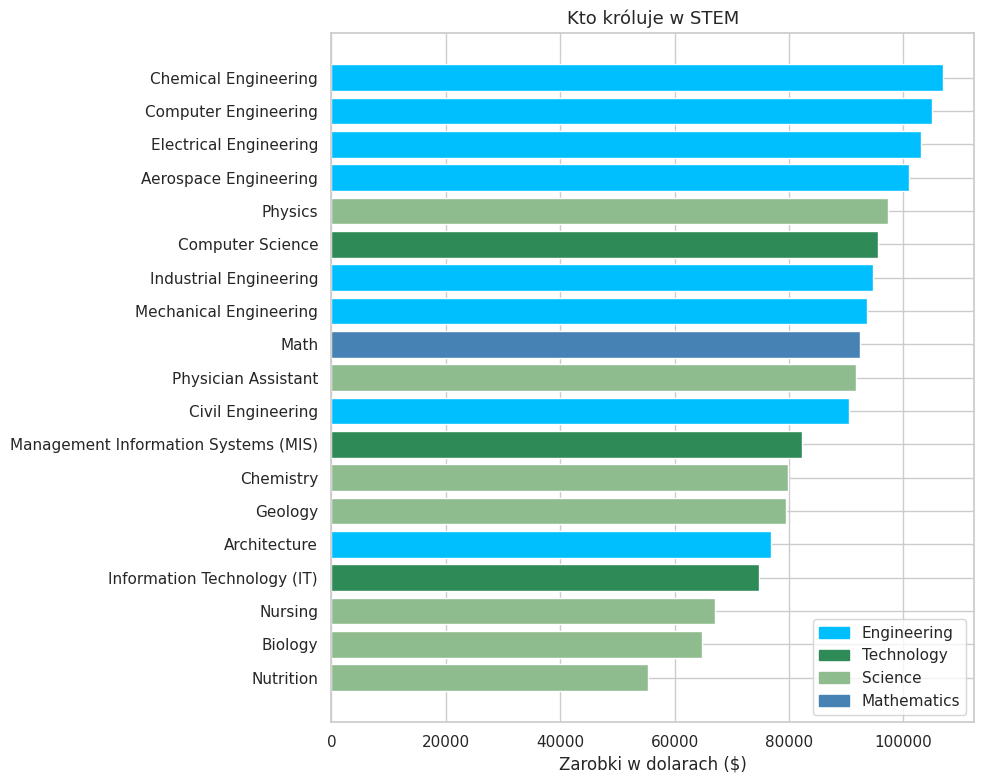

In [110]:
# Kto króluje w STEM
stem_only = degree[degree['category'] == 'STEM'].sort_values('career_mid')

fig, ax = plt.subplots(figsize=(10, 8))
colors = stem_only['type'].map(type_colors)
ax.barh(stem_only['major'], stem_only['career_mid'], color=colors)

handles = [mpatches.Patch(color=type_colors[t], label=t)
           for t in ['Engineering', 'Technology', 'Science', 'Mathematics']]
ax.legend(handles=handles)
ax.set_title('Kto króluje w STEM', fontsize=13)
ax.set_xlabel('Zarobki w dolarach ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Już na pierwszy rzut oka widać wyraźną przewagę kierunków inżynieryjnych (Engineering). Termin „STEM" jest nadużywany jako gwarancja sukcesu. Prawdziwe pieniądze leżą w „TE".

### Pytanie 4: Wskazanie kierunków „bezpiecznych" oraz tych o wysokim risk/reward.

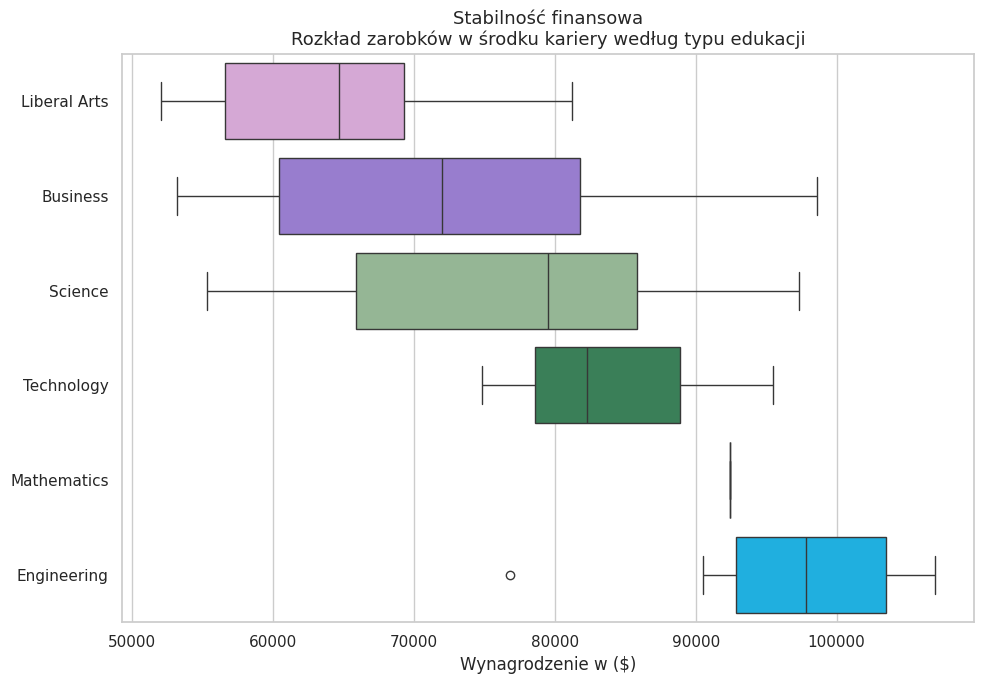

In [122]:
# Boxplot stabilności finansowej
order = degree.groupby('type')['career_mid'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(
    data=degree, x='career_mid', y='type', order=order, hue='type', palette=type_colors, ax=ax,
)
ax.set_title('Stabilność finansowa\nRozkład zarobków w środku kariery według typu edukacji', fontsize=13)
ax.set_xlabel('Wynagrodzenie w ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

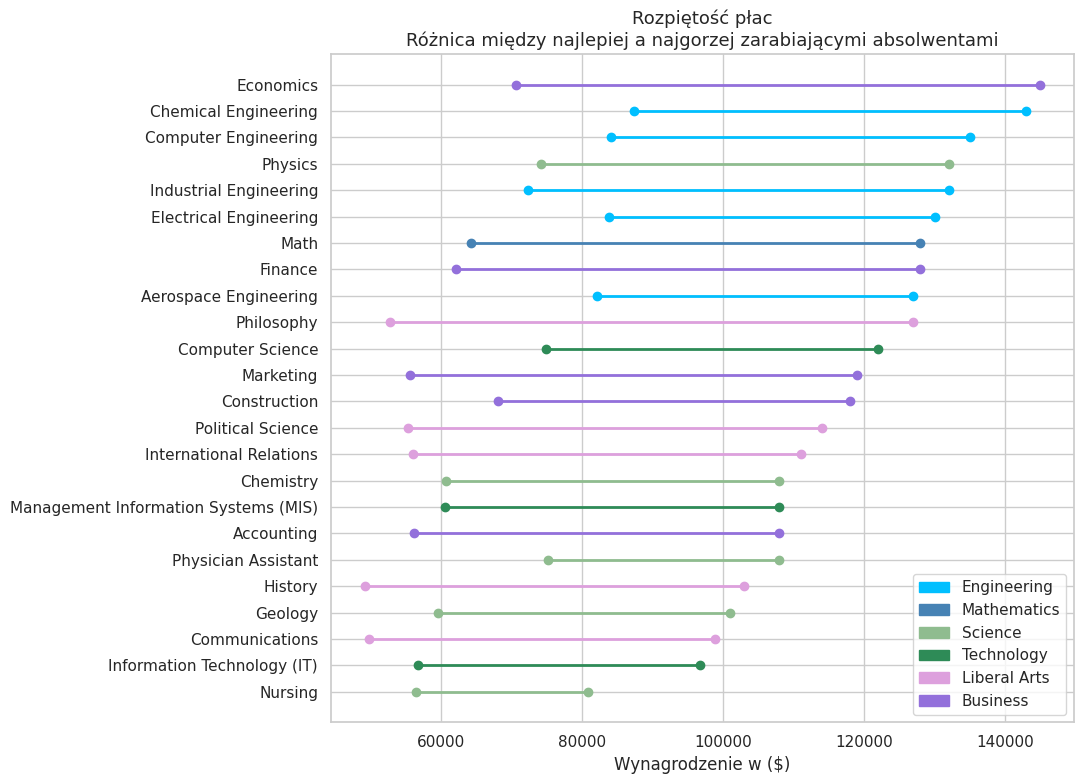

In [112]:
# Dumbbell - rozpiętość płac (p25 vs p75), top 5 per type
top5_p75 = (
    degree.groupby('type')
    .apply(lambda g: g.nlargest(5, 'career_mid'))
    .reset_index(level=0)
    .dropna(subset=['p25_salary', 'p75_salary'])
    .sort_values('p75_salary')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 8))
for _, row in top5_p75.iterrows():
    color = type_colors.get(row['type'], 'gray')
    ax.plot([row['p25_salary'], row['p75_salary']], [row['major'], row['major']],
            color=color, linewidth=2)
    ax.scatter([row['p25_salary'], row['p75_salary']], [row['major'], row['major']],
               color=color, zorder=5)

handles = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=handles, loc='lower right')
ax.set_title('Rozpiętość płac\nRóżnica między najlepiej a najgorzej zarabiającymi absolwentami', fontsize=13)
ax.set_xlabel('Wynagrodzenie w ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Niespodziewanie pozycję numer jeden zajmuje Ekonomia o bardzo szerokiej rozpiętości. Oznacza to niepewne zarobki przyszłościowe dla absolwentów.

### Pytanie 5: Sufit zarobkowy: STEM vs. Biznes
Sprawdzenie, która z grup szybciej osiąga pełny potencjał zarobkowy.

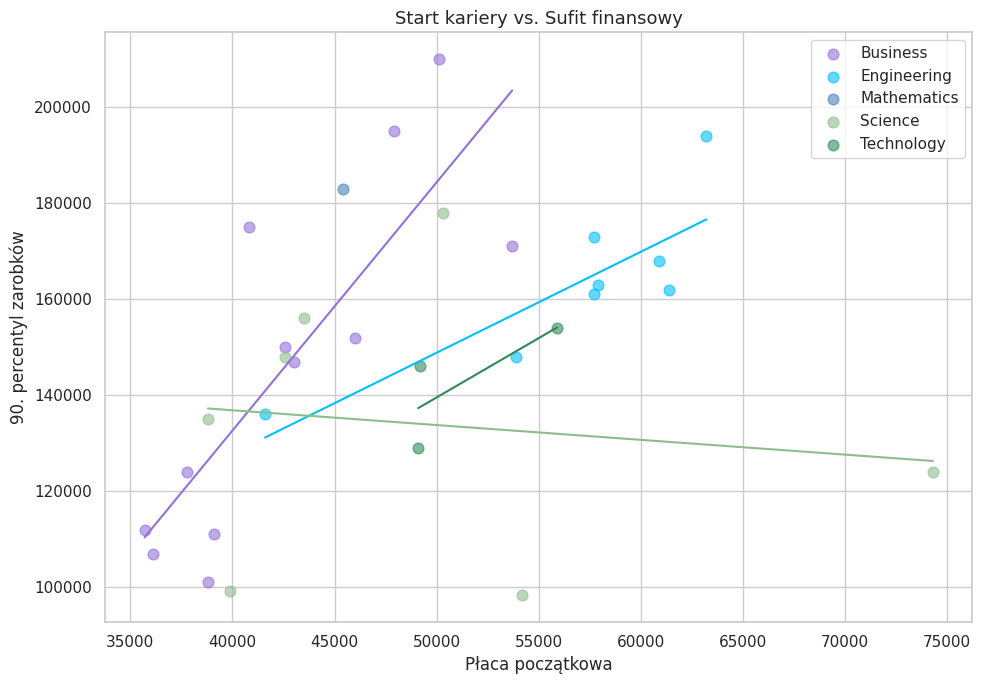

In [113]:
# Scatter: career_start vs p90_salary dla STEM i Business
subset5 = degree[(degree['type'] == 'Business') | (degree['category'] == 'STEM')].dropna(subset=['p90_salary'])

fig, ax = plt.subplots(figsize=(10, 7))
for t, grp in subset5.groupby('type'):
    color = type_colors.get(t, 'gray')
    ax.scatter(grp['career_start'], grp['p90_salary'], color=color, s=60, alpha=0.6, label=t)
    # linia regresji
    if len(grp) > 1:
        m, b = np.polyfit(grp['career_start'], grp['p90_salary'], 1)
        xs = np.linspace(grp['career_start'].min(), grp['career_start'].max(), 100)
        ax.plot(xs, m * xs + b, color=color, linewidth=1.5)

ax.legend()
ax.set_title('Start kariery vs. Sufit finansowy', fontsize=13)
ax.set_xlabel('Płaca początkowa')
ax.set_ylabel('90. percentyl zarobków')
plt.tight_layout()
plt.show()

Na wykresie powyżej widać w sposób dosłowny sufit finansowy. "Business" zaczyna nisko lecz niesamowicie wysoko wystrzela zakładając najlepsze dla studenta warunki.

### Pytanie 6: Anomalie wśród kierunków nie-STEM
Identyfikacja konkretnych kierunków które przechodzą niestandardowy dla swojej kategorii wzrost.

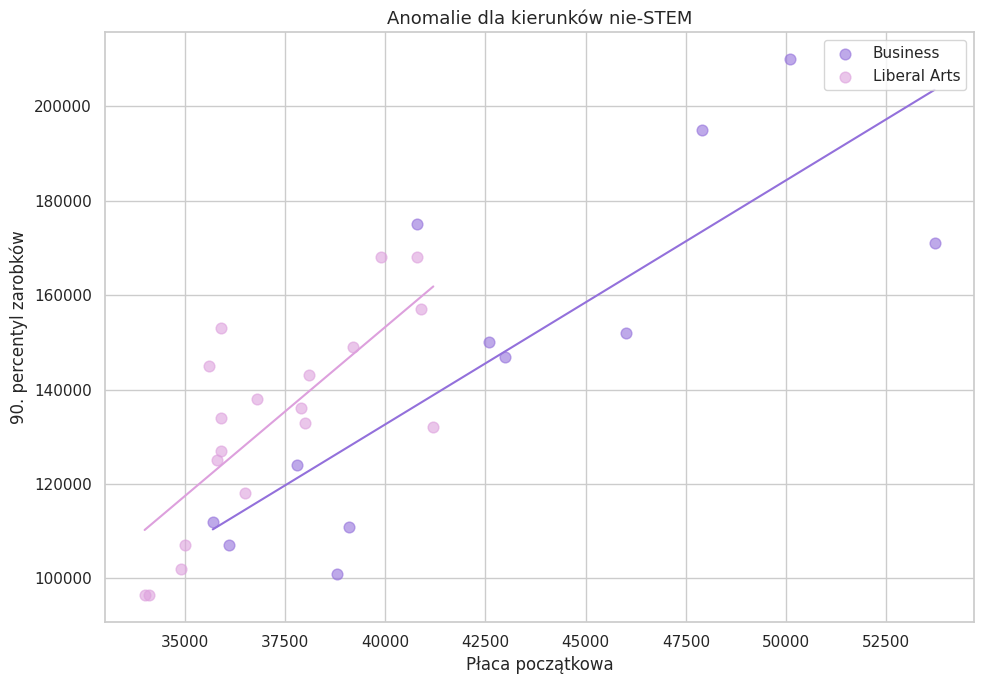

In [114]:
# Scatter: Others - career_start vs p90_salary
others_df = degree[degree['category'] == 'Others'].dropna(subset=['p90_salary'])

fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {'Liberal Arts': 'plum', 'Business': 'mediumpurple'}
for t, grp in others_df.groupby('type'):
    color = colors_map.get(t, 'gray')
    ax.scatter(grp['career_start'], grp['p90_salary'], color=color, s=60, alpha=0.6, label=t)
    if len(grp) > 1:
        m, b = np.polyfit(grp['career_start'], grp['p90_salary'], 1)
        xs = np.linspace(grp['career_start'].min(), grp['career_start'].max(), 100)
        ax.plot(xs, m * xs + b, color=color, linewidth=1.5)

ax.legend()
ax.set_title('Anomalie dla kierunków nie-STEM', fontsize=13)
ax.set_xlabel('Płaca początkowa')
ax.set_ylabel('90. percentyl zarobków')
plt.tight_layout()
plt.show()

Widać, iż większość Outlierów pochodzi z kategorii business - oprócz filozofii (Philosophy). Pozostałe kierunki układają się w podobnej ćwiartce wykresu.

In [115]:
print("Typy uczelni (college):")
print(college['type'].value_counts())
print("\nRegiony (region):")
print(region['Region'].value_counts())

Typy uczelni (college):
type
State           175
Liberal Arts     47
Party            20
Engineering      19
Ivy League        8
Name: count, dtype: int64

Regiony (region):
Region
Northeastern    100
Southern         79
Midwestern       71
Western          42
California       28
Name: count, dtype: int64


Przeglądając pozostałe dwa datasety, rzucają się w oczy wartości typu uczelni i regionu. Tu typ uczelni "engineering" to nie to samo co kierunek "engineering", choć sugeruje, iż na takiej uczelni istnieje dużo inżynierskich kierunków.

### Pytanie 7: Prestiż Ivy League vs. State Schools
Czy „historyk z Harvardu" zarabia więcej niż „informatyk z uczelni stanowej"? Czy nazwa uczelni niweluje różnice między kierunkami?

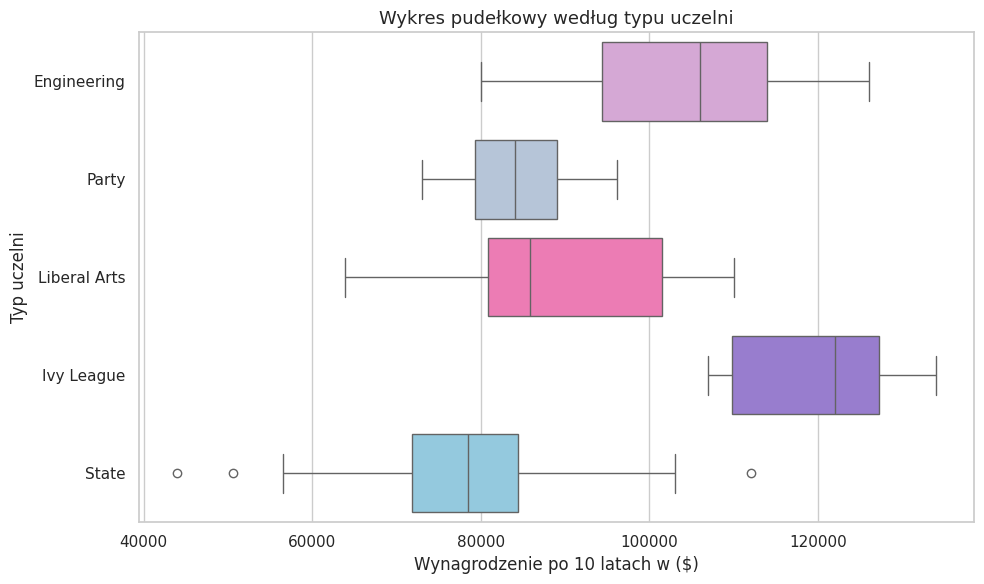

In [116]:
# Boxplot według typu uczelni
college_colors = {
    'Engineering': 'plum',
    'Ivy League': 'mediumpurple',
    'Liberal Arts': 'hotpink',
    'Party': 'lightsteelblue',
    'State': 'skyblue'
}

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=college, x='career_mid', y='type',
    hue='type', palette=college_colors, ax=ax
)
ax.set_title('Wykres pudełkowy według typu uczelni', fontsize=13)
ax.set_xlabel('Wynagrodzenie po 10 latach w ($)')
ax.set_ylabel('Typ uczelni')
plt.tight_layout()
plt.show()

In [117]:
# Statystyki dla Ivy League, State, Engineering
ivystate = (
    college[college['type'].isin(['Ivy League', 'State', 'Engineering'])]
    .groupby('type')
    .agg(
        count=('career_mid', 'count'),
        median_start=('career_start', 'median'),
        median_mid=('career_mid', 'median'),
        p10=('p10_salary', lambda x: x.median()),
        p90=('p90_salary', lambda x: x.median()),
        max_mid=('career_mid', 'max')
    )
    .sort_values('median_mid', ascending=False)
)
display(ivystate)

,count,median_start,median_mid,p10,p90,max_mid
type,,,,,,
Ivy League,8,59850.00,122000.00,56350.00,271500.00,134000.00
Engineering,19,58300.00,106000.00,63300.00,180000.00,126000.00
State,175,43600.00,78500.00,41700.00,147000.00,112000.00


Zazwyczaj uczelnie typu Engineering oferują wyższy start niż Ivy League, a najniżej wynagradzani inżynierowie również zarabiają lepiej niż ich rówieśnicy z innych grup. Ivy League często jednak przegania kierunki techniczne po 10 latach pracy.

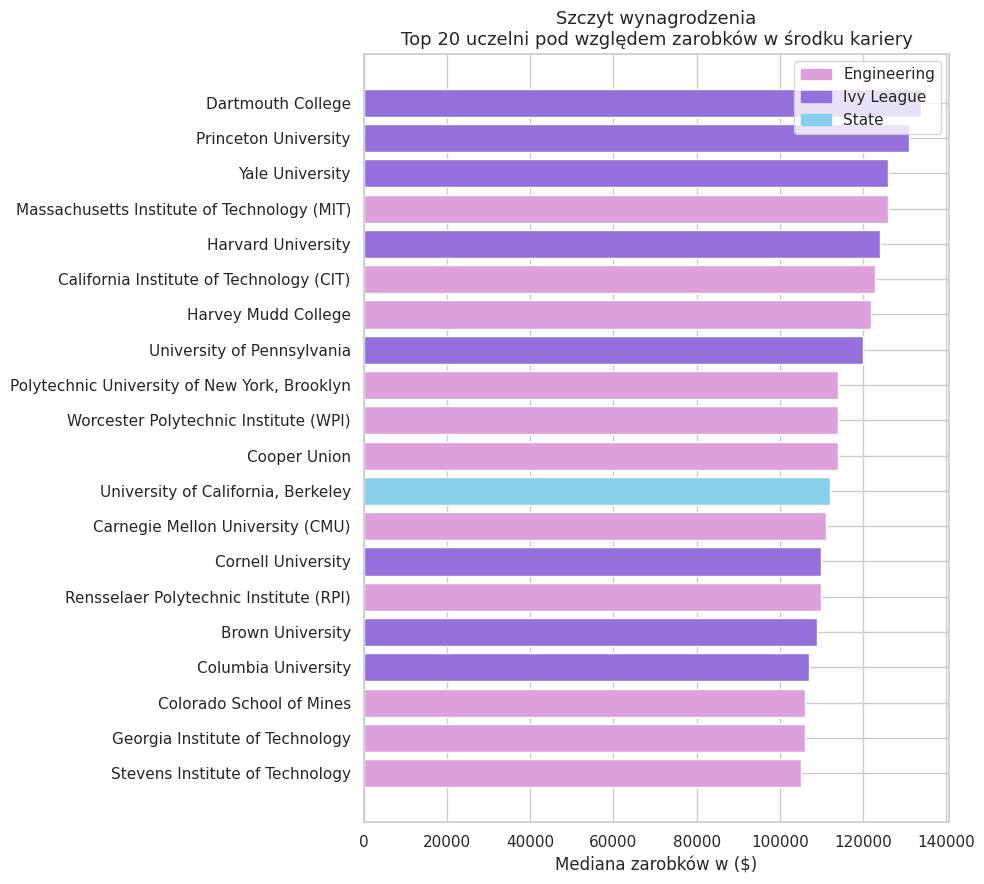

In [118]:
# Top 20 uczelni wg career_mid
top20 = (
    college[college['type'].isin(['Ivy League', 'State', 'Engineering'])]
    .nlargest(20, 'career_mid')
    .sort_values('career_mid')
)

fig, ax = plt.subplots(figsize=(10, 9))
colors_top20 = top20['type'].map({'Engineering': 'plum', 'Ivy League': 'mediumpurple', 'State': 'skyblue'})
ax.barh(top20['university'], top20['career_mid'], color=colors_top20)

handles = [
    mpatches.Patch(color='plum', label='Engineering'),
    mpatches.Patch(color='mediumpurple', label='Ivy League'),
    mpatches.Patch(color='skyblue', label='State')
]
ax.legend(handles=handles)
ax.set_title('Szczyt wynagrodzenia\nTop 20 uczelni pod względem zarobków w środku kariery', fontsize=13)
ax.set_xlabel('Mediana zarobków w ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Pytanie 8: Korelacja między stabilnością finansową a typem uczelni

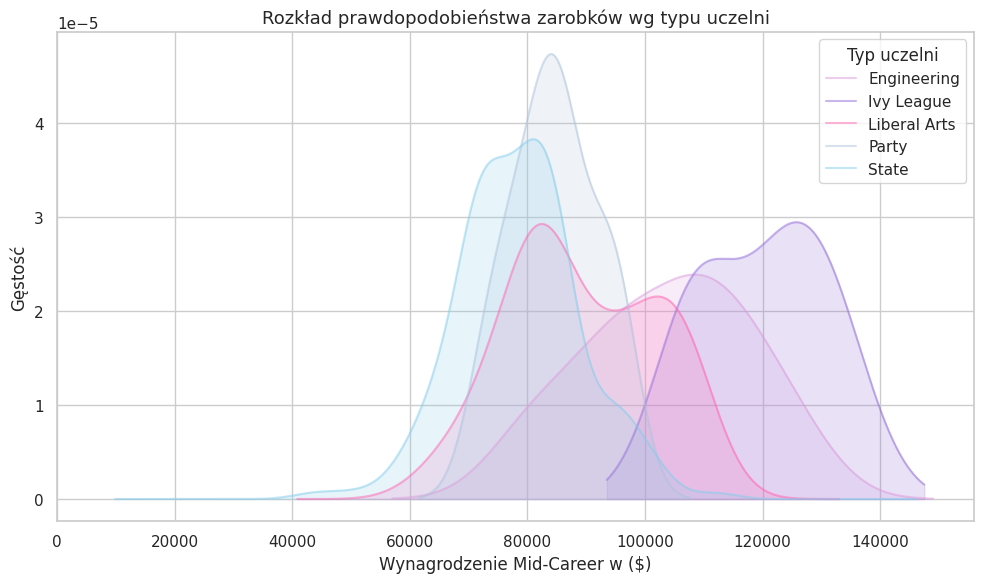

In [119]:
# Density plot wg typu uczelni
fig, ax = plt.subplots(figsize=(10, 6))
for t, grp in college.groupby('type'):
    color = college_colors.get(t, 'gray')
    grp['career_mid'].dropna().plot.kde(ax=ax, label=t, color=color, alpha=0.5)
    ax.fill_between(
        ax.lines[-1].get_xdata(),
        ax.lines[-1].get_ydata(),
        alpha=0.2, color=color
    )

ax.set_title('Rozkład prawdopodobieństwa zarobków wg typu uczelni', fontsize=13)
ax.set_xlabel('Wynagrodzenie Mid-Career w ($)')
ax.set_ylabel('Gęstość')
ax.legend(title='Typ uczelni')
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

Krzywa dla Ivy League jest najbardziej wysunięta na prawo, co potwierdza wcześniejsze wnioski iż prestiż uczelni daje lepszy start w karierze.

### Pytanie 9: Porównanie Regionów USA
Który region oferuje największą pomoc w przyszłych zarobkach.

In [120]:
statsregion = (
    region.groupby('Region')['career_mid']
    .agg(
        count='count',
        mean_start='mean',
        mean_mid='median',
        sd='std',
        min='min',
        max='max'
    )
    .sort_values('mean_mid', ascending=False)
)
display(statsregion)

,count,mean_start,mean_mid,sd,min,max
Region,,,,,,
California,28,93132.14,91550.00,15787.71,67500.00,129000.00
Northeastern,100,91352.00,88700.00,15103.02,62600.00,134000.00
Southern,79,79505.06,79400.00,14067.59,51000.00,110000.00
Western,42,78200.00,78850.00,9743.74,50600.00,106000.00
Midwestern,71,78180.28,77800.00,12997.69,43900.00,116000.00


Odznaczające się dwa regiony to Northeastern i California – co nie powinno nikogo zdziwić. To wybrzeże to miejsce powstania prestiżowych uczelni takich jak MIT, Yale, Princeton czy Stanford.

### Pytanie 10: Czy istnieje „Złoty bilet" do lepszych zarobków – i podsumowanie wyników.

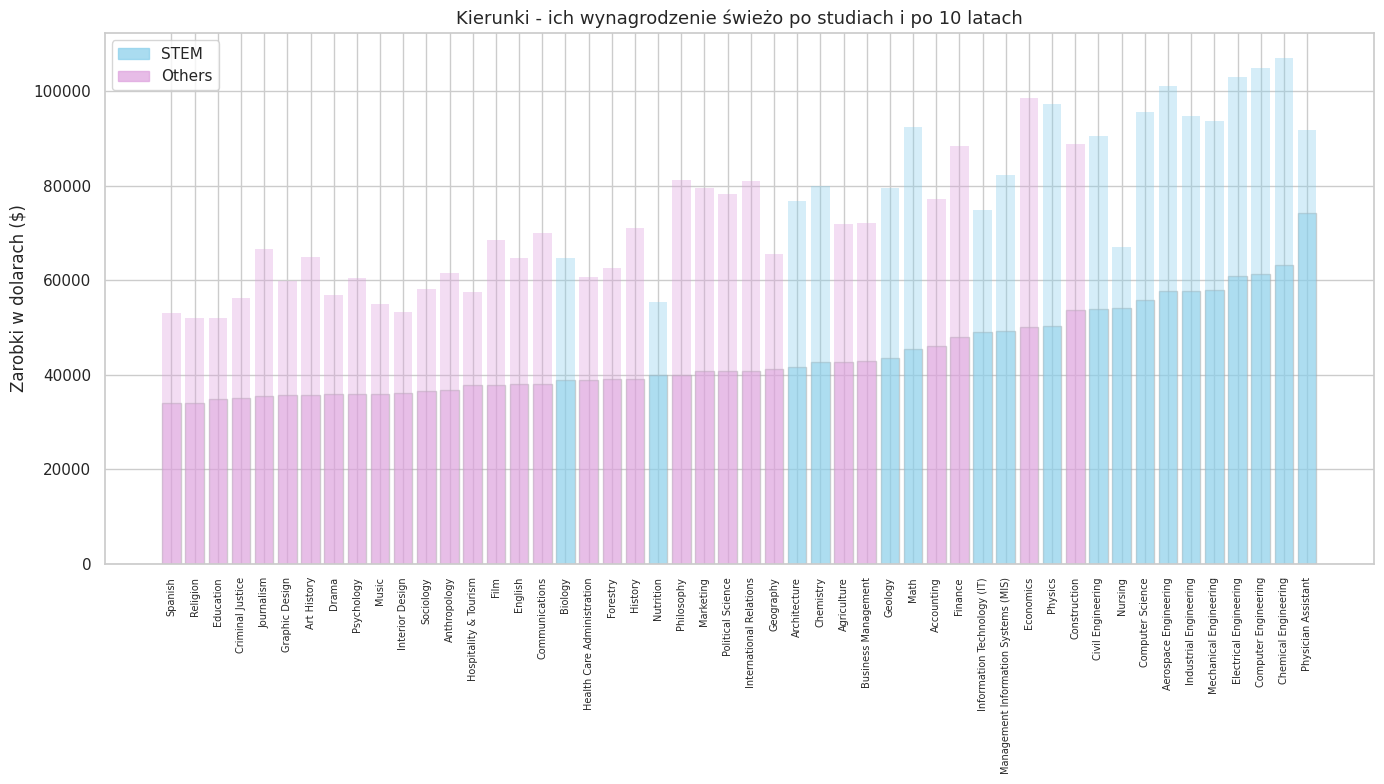

In [121]:
# Wykres słupkowy: career_start i career_mid dla każdego kierunku
degree_sorted = degree.sort_values('career_start')

fig, ax = plt.subplots(figsize=(14, 8))
cat_colors = {'STEM': 'skyblue', 'Others': 'plum'}
bar_colors = degree_sorted['category'].map(cat_colors)

x = range(len(degree_sorted))
ax.bar(x, degree_sorted['career_start'], color=bar_colors, alpha=0.5, edgecolor='darkgray', label='Start kariery')
ax.bar(x, degree_sorted['career_mid'], color=bar_colors, alpha=0.35, edgecolor='none', label='Po 10 latach')

handles = [
    mpatches.Patch(color='skyblue', alpha=0.7, label='STEM'),
    mpatches.Patch(color='plum', alpha=0.7, label='Others')
]
ax.legend(handles=handles)
ax.set_xticks(list(x))
ax.set_xticklabels(degree_sorted['major'], rotation=90, fontsize=7)
ax.set_title('Kierunki - ich wynagrodzenie świeżo po studiach i po 10 latach', fontsize=13)
ax.set_ylabel('Zarobki w dolarach ($)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

Ostatni wykres pokazuje pełny krajobraz opłacalności studiów. Choć kolory błękitne (STEM) dominują w górnej części wykresu, potwierdzając swoją rynkową siłę, to rozpiętość słupków fioletowych (Others) ujawnia ogromny potencjał kierunków biznesowych i humanistycznych. Ostatecznie „Złoty Bilet" to nie tylko wybór kierunku z wysokim startem, ale świadomość, że w niektórych dziedzinach (Economics, Finance) prawdziwy zysk finansowy przychodzi dopiero z czasem, często wyrównując szanse w starciu z inżynierami i informatykami.

Mogę jedynie słownie podsumować stan aktualnego wynagrodzenia (a nie tego sprzed 9 lat) w którym nie powinniśmy zobaczyć za dużych różnic z tym co przedstawiłam powyżej. STEM będzie królować na długo, gdyż jest katalizatorem kroków w przyszłość - choć próg wejściowy na ten rynek staje się coraz trudniejszy (za czym stoi dynamiczny rozwój sztucznej inteligencji).

**„Złotym Biletem"** na przyszłość to nie tylko *co* studiujemy ("TE" z pojęcia STEM) ale przede wszystkim *gdzie* (na zachodnim wybrzeżu Ameryki czy może na AGH...), gdyż doedukować można się przez internet lub publiczne biblioteki, ale zawarcie kontaktów przyszłościowych to jedna z największych zalet prestiżowej uczelni.

---
